In [1]:
import os

import numpy as np
import scanpy as sc
from kneed import KneeLocator
import h5py

import seaborn as sns
import matplotlib.pyplot as plt

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS/'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS.preprocess import get_tf_activity, tf_to_adata
from scLEMBAS import io


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
seed = 888

In [3]:
author = 'Replogle'

# Preprocessing of gene expression:

In [4]:
rpe1 = sc.read_h5ad(os.path.join(data_path, 'raw', 'rpe1_normalized_singlecell_01.h5ad'))
rpe1_scperturb = sc.read_h5ad(os.path.join(data_path, 'raw', 'scperturb_ReplogleWeissman2022_rpe1.h5ad'))

k562 = sc.read_h5ad(os.path.join(data_path, 'raw', 'K562_essential_normalized_singlecell_01.h5ad'))
k562_scperturb = sc.read_h5ad(os.path.join(data_path, 'raw', 'scperturb_ReplogleWeissman2022_K562_essential.h5ad'))

Some basic QC:

In [5]:
# # this doesn't filter anything out -- good sign, indicates already QC'd
# sc.pp.filter_cells(rpe1, min_genes=100)
# sc.pp.filter_genes(rpe1, min_cells=100)

# sc.pp.filter_cells(k562, min_genes=100)
# sc.pp.filter_genes(k562, min_cells=100)

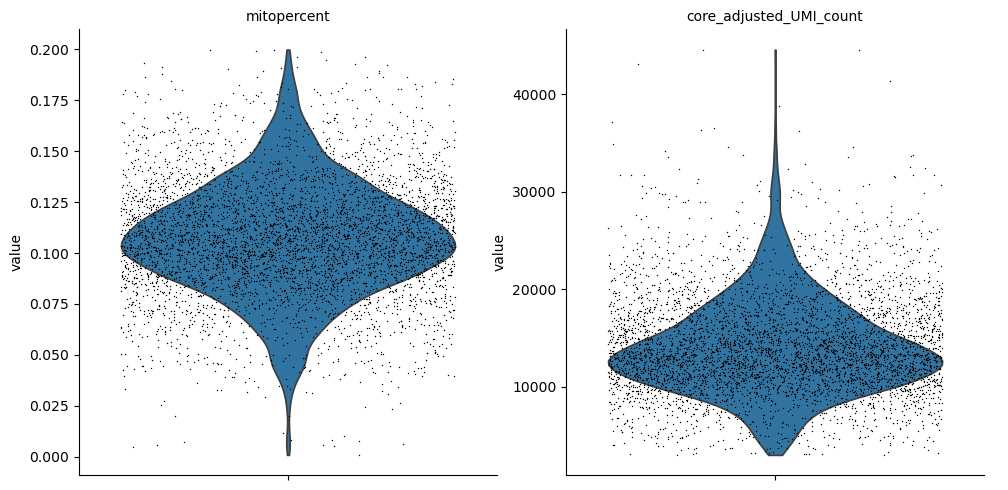

In [6]:
np.random.seed(seed)
subset = np.random.choice(k562.obs_names, int(5e3), replace = False)
sc.pl.violin(
    k562[subset, :],
    ["mitopercent", "core_adjusted_UMI_count"],
    jitter=0.4,
    multi_panel=True,
)

# filters out 969 out of 310385 cells
k562 = k562[k562.obs["core_adjusted_UMI_count"] < int(35e3), :]

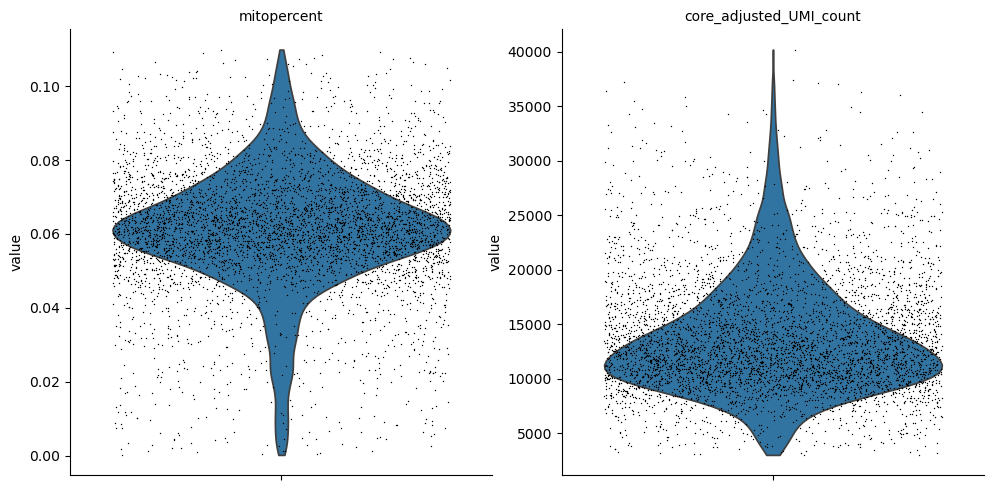

In [7]:
np.random.seed(seed)
subset = np.random.choice(rpe1.obs_names, int(5e3), replace = False)
sc.pl.violin(
    rpe1[subset, :],
    ["mitopercent", "core_adjusted_UMI_count"],
    jitter=0.4,
    multi_panel=True,
)

# filters out 771 out of 247914 cells
rpe1 = rpe1[rpe1.obs["core_adjusted_UMI_count"] < int(35e3), :]

Use scPerturb data to map the ENSG to the gene names:

In [8]:
if rpe1_scperturb.var.ensembl_id.nunique() != rpe1_scperturb.var.shape[0]:
    raise ValueError('There is a not a 1-to-1 mapping of gene name to ensembl ID')
if sorted(rpe1_scperturb.var.ensembl_id) != sorted(rpe1.var_names):
    raise ValueError('There is not a 1-to-1 correspondence between the original data and scPerturb')
    
gene_map = dict(zip(rpe1_scperturb.var.ensembl_id, rpe1_scperturb.var.index))
rpe1.var_names = rpe1.var_names.map(gene_map)
del rpe1_scperturb

In [9]:
if k562_scperturb.var.ensembl_id.nunique() != k562_scperturb.var.shape[0]:
    raise ValueError('There is a not a 1-to-1 mapping of gene name to ensembl ID')
if sorted(k562_scperturb.var.ensembl_id) != sorted(k562.var_names):
    raise ValueError('There is not a 1-to-1 correspondence between the original data and scPerturb')
    
gene_map = dict(zip(k562_scperturb.var.ensembl_id, k562_scperturb.var.index))
k562.var_names = k562.var_names.map(gene_map)
del k562_scperturb

Exclude perturbations with fewer than 50 cells:

In [10]:
thresh = 50

''

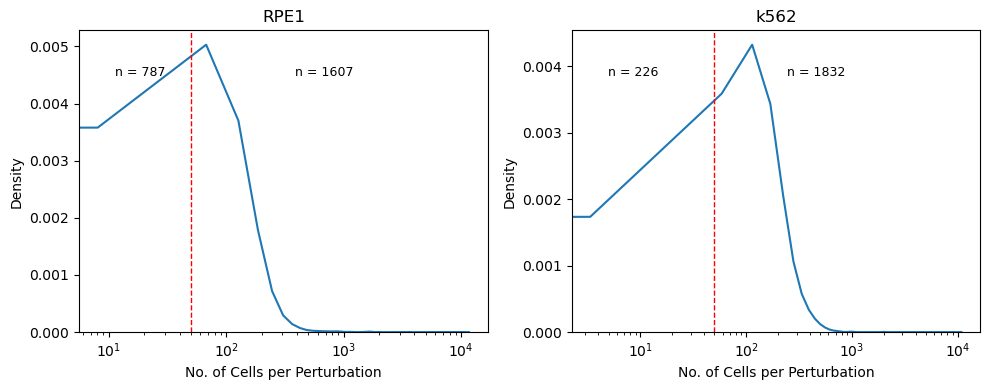

In [11]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,4))
sns.kdeplot(rpe1.obs.gene.value_counts(), ax = ax[0])
ax[0].set_xscale('log')
ax[0].set_xlabel('No. of Cells per Perturbation')
ax[0].set_title('RPE1')
ax[0].axvline(x=thresh, color='r', linestyle='--', linewidth=1)


n_perturbations_og = rpe1.obs.gene.nunique()
retain = rpe1.obs.gene.value_counts()[rpe1.obs.gene.value_counts() >= thresh].index.tolist()
rpe1 = rpe1[rpe1.obs.gene.isin(retain),:]
n_perturbations = rpe1.obs.gene.nunique()
# print('RPE1: Filtering for perturbations present in atleast {} single-cells decreases the no. of perturbations from {} to {}'.format(thresh, n_perturbations_og, ))


ax[0].annotate('n = {}'.format(n_perturbations_og - n_perturbations), xy=(0.15, 0.85), xycoords='axes fraction',
            fontsize=9, color='black', ha='center')
ax[0].annotate('n = {}'.format(n_perturbations), xy=(0.6, 0.85), xycoords='axes fraction',
            fontsize=9, color='black', ha='center')



sns.kdeplot(k562.obs.gene.value_counts(), ax = ax[1])
ax[1].set_xscale('log')
ax[1].set_xlabel('No. of Cells per Perturbation')
ax[1].set_title('k562')
ax[1].axvline(x=thresh, color='r', linestyle='--', linewidth=1)


n_perturbations_og = k562.obs.gene.nunique()
retain = k562.obs.gene.value_counts()[k562.obs.gene.value_counts() >= thresh].index.tolist()
k562 = k562[k562.obs.gene.isin(retain),:]
n_perturbations = k562.obs.gene.nunique()
# print('k562: Filtering for perturbations present in atleast {} single-cells decreases the no. of perturbations from {} to {}'.format(thresh, n_perturbations_og, ))


ax[1].annotate('n = {}'.format(n_perturbations_og - n_perturbations), xy=(0.15, 0.85), xycoords='axes fraction',
            fontsize=9, color='black', ha='center')
ax[1].annotate('n = {}'.format(n_perturbations), xy=(0.6, 0.85), xycoords='axes fraction',
            fontsize=9, color='black', ha='center')

fig.tight_layout()
;

# Start

In [12]:
# k562backup = k562.copy()
# rpe1backup = rpe1.copy()

# # k562 = k562backup.copy()
# # rpe1 = rpe1backup.copy()

In [13]:
# # TDO DELETE
# np.random.seed(seed)
# subset_cells = np.random.choice(k562.obs_names, int(5e2), replace = False)
# subset_genes = np.random.choice(k562.var_names, int(1e3), replace = False)
# k562 = k562[subset_cells, subset_genes]


# np.random.seed(seed)
# subset_cells = np.random.choice(rpe1.obs_names, int(5e2), replace = False)
# subset_genes = np.random.choice(rpe1.var_names, int(1e3), replace = False)
# rpe1 = rpe1[subset_cells, subset_genes]

# End

In [14]:
batch_key = 'batch'
rpe1.obs[batch_key] = 'rpe1'
k562.obs[batch_key] = 'k562'

adata = sc.concat([rpe1, k562], label=None)
adata.obs_names_make_unique()

adata

/tmp/ipykernel_3979817/3670908244.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  rpe1.obs[batch_key] = 'rpe1'
/tmp/ipykernel_3979817/3670908244.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  k562.obs[batch_key] = 'k562'


AnnData object with n_obs × n_vars = 1000 × 92
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'batch'

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


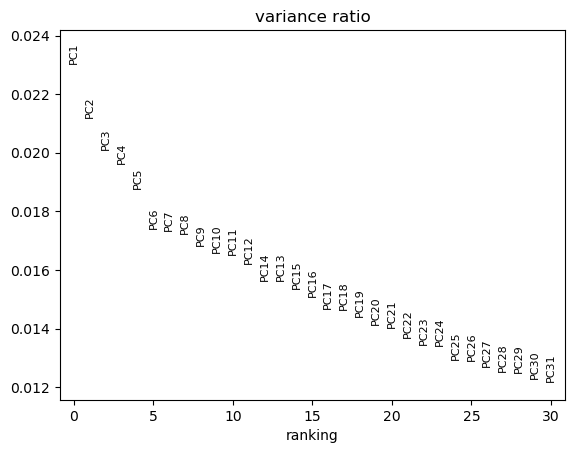

The elbow was automatically identified at PC 6


In [15]:
# sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key=None, flavor = 'seurat')
sc.tl.pca(adata, 
          zero_center = False, # rather than used scaled data, calculates covariance matrix internally
          n_comps = 50,
          random_state = seed, 
          use_highly_variable = False,
         )

variance_ratio = adata.uns['pca']['variance_ratio']
pcs = np.array(range(len(variance_ratio))) + 1
kneedle = KneeLocator(x = pcs, y = variance_ratio, curve='convex', direction='decreasing')
adata.uns['pca']['pca_rank'] = kneedle.elbow
sc.pl.pca_variance_ratio(adata)
print('The elbow was automatically identified at PC {}'.format(adata.uns['pca']['pca_rank']))

In [16]:
sc.pp.neighbors(adata, n_pcs = adata.uns['pca']['pca_rank'])
sc.tl.umap(adata)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


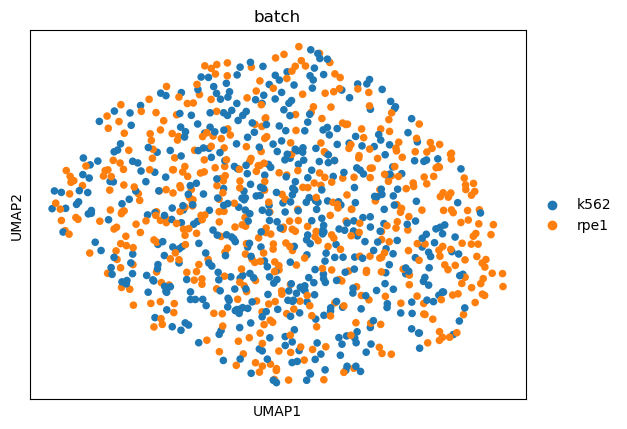

In [17]:
np.random.seed(seed)
cell_order = np.random.permutation(adata.obs_names)
sc.pl.umap(adata[cell_order, :], color=[batch_key], wspace=1)


We can see that while there is mixing between the two datasets, there does also appear to be batch-specific separation. So, let's correct the batch as described [here](https://www.sc-best-practices.org/cellular_structure/integration.html#linear-embedding-integration-using-mutual-nearest-neighbors-mnn).

array([[-0.3361087 , -0.889083  , -1.8057597 , ...,  0.29314113,
        -1.1925387 , -0.35967213],
       [ 2.601309  , -0.5313272 , -0.981462  , ..., -0.9573471 ,
         0.7879743 ,  0.674003  ],
       [ 0.17219551, -0.57368994, -0.039296  , ..., -0.7011822 ,
         0.9283515 ,  0.22086813],
       ...,
       [ 1.8644508 ,  1.9736156 ,  2.4786956 , ..., -0.51791936,
        -0.706652  , -0.02357808],
       [ 0.32909894, -0.7912307 ,  2.2641194 , ...,  0.39613912,
        -0.39179638, -0.5328697 ],
       [ 0.62783194,  1.8108643 , -0.92038536, ..., -0.01507668,
         1.3368781 ,  1.0097562 ]], dtype=float32)

In [22]:
adata.write_h5ad(os.path.join(data_path, 'interim', author + 'expr_merged_adata.h5ad'))

# for R:
with h5py.File(os.path.join(data_path, 'interim', author + 'expr_merged.h5'), "w") as f:
    f.create_dataset("array", data=adata.X)
    
with h5py.File(os.path.join(data_path, 'interim', author + 'pca_merged.h5'), "w") as f:
    f.create_dataset("X_pca", data=adata.obsm['X_pca'])
    
with open(os.path.join(data_path, 'interim', author + 'expr_md.txt'), "w") as file:
    for item in adata.obs.batch.tolist():
        file.write(f"{item}\n")

with open(os.path.join(data_path, 'interim', author + 'expr_obs_names.txt'), "w") as file:
    for item in adata.obs_names.tolist():
        file.write(f"{item}\n")
        
with open(os.path.join(data_path, 'interim', author + 'expr_var_names.txt'), "w") as file:
    for item in adata.var_names.tolist():
        file.write(f"{item}\n")